# 1. Data Preparation
## 1.1 Load the Data
Load the synthetic data (e.g., NLS_Group03.txt) and split it into two classes based on the file's structure.

In [6]:
import numpy as np
import random
import matplotlib.pyplot as plt 

# Load data from the file and split into two classes
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

# Assuming the first line is a header and skipping it
lines = lines[1:]

# Split data into classes (first 2447 lines belong to Class 1, and the rest to Class 2)
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line.strip().split())
    else:  # Class 2
        class2_data.append(line.strip().split())

# Convert to NumPy arrays for easier manipulation
class1_data = np.array(class1_data, dtype=float)
class2_data = np.array(class2_data, dtype=float)

In [3]:
class1_data, class2_data

(array([[ 1.006419,  7.971535],
        [-8.568597, -0.994905],
        [-7.830411, -6.082278],
        ...,
        [-3.278219,  7.467189],
        [-6.272387,  5.801146],
        [ 6.151147,  9.607727]]),
 array([[-5.057229, -3.588552],
        [ 1.023803,  5.159661],
        [ 1.479217, 11.794899],
        ...,
        [ 7.845237,  8.196611],
        [-2.968971, -6.084928],
        [-1.417023,  5.735476]]))

In [9]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Load data from the file and split into two classes
with open('NLS_Group03.txt', 'r') as f:
    lines = f.readlines()

# Assuming the first line is a header and skipping it
lines = lines[1:]

# Split data into classes (first 2447 lines belong to Class 1, and the rest to Class 2)
class1_data = []
class2_data = []

for i, line in enumerate(lines):
    if i <= 2446:  # Class 1
        class1_data.append(line.strip().split())
    else:  # Class 2
        class2_data.append(line.strip().split())

# Convert to NumPy arrays for easier manipulation
class1_data = np.array(class1_data, dtype=float)
class2_data = np.array(class2_data, dtype=float)

# Function for initializing centroids
def initialize_centroids(data, k):
    # Randomly select 'k' data points as initial centroids
    indices = random.sample(range(len(data)), k)
    centroids = data[indices]
    return centroids

# Function to assign clusters based on nearest centroids
def assign_clusters(data, centroids):
    clusters = []
    for point in data:
        distances = np.linalg.norm(point - centroids, axis=1)  # Calculate Euclidean distance
        closest_centroid = np.argmin(distances)  # Find the closest centroid
        clusters.append(closest_centroid)
    return np.array(clusters)

# Function to update centroids based on cluster assignments
def update_centroids(data, clusters, k):
    new_centroids = []
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            new_centroid = np.mean(cluster_points, axis=0)
        else:
            new_centroid = random.choice(data)  # Handle empty clusters
        new_centroids.append(new_centroid)
    return np.array(new_centroids)

# Function to perform k-means clustering
def kmeans(data, k, max_iterations=100):
    centroids = initialize_centroids(data, k)  # Step 1: Initialize centroids
    for _ in range(max_iterations):
        clusters = assign_clusters(data, centroids)  # Step 2: Assign clusters
        new_centroids = update_centroids(data, clusters, k)  # Step 3: Update centroids
        if np.all(centroids == new_centroids):  # If centroids haven't changed, convergence is reached
            break
        centroids = new_centroids
    return centroids, clusters

# Function for Gaussian Mixture Model (GMM) using Expectation-Maximization (EM)
def gmm(data, k, max_iterations=100):
    n, d = data.shape

    # Step 1: Initialize GMM parameters
    weights = np.ones(k) / k  # Uniform weights
    means = initialize_centroids(data, k)  # Initialize means using k-means centroids
    covariances = np.array([np.cov(data, rowvar=False) for _ in range(k)])  # Initial covariance matrices

    def gaussian_pdf(x, mean, cov):
        """Multivariate Gaussian probability density function."""
        d = len(mean)
        exponent = -0.5 * np.dot((x - mean).T, np.linalg.solve(cov, (x - mean)))
        denominator = np.sqrt((2 * np.pi) ** d * np.linalg.det(cov))
        return np.exp(exponent) / denominator

    # Step 2: EM algorithm
    for _ in range(max_iterations):
        # E-step: Calculate responsibilities
        responsibilities = np.zeros((n, k))
        for i in range(k):
            for j in range(n):
                responsibilities[j, i] = weights[i] * gaussian_pdf(data[j], means[i], covariances[i])
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)  # Normalize

        # M-step: Update weights, means, and covariances
        Nk = responsibilities.sum(axis=0)  # Effective number of points assigned to each cluster
        weights = Nk / n
        means = np.dot(responsibilities.T, data) / Nk[:, None]
        covariances = np.zeros((k, d, d))
        for i in range(k):
            diff = data - means[i]
            covariances[i] = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]

    return means, covariances, weights, responsibilities

# Function to plot results with consistent color scheme
def plot_clusters(data, clusters, centroids, title, cmap):
    plt.scatter(data[:, 0], data[:, 1], c=clusters, s=30, cmap=cmap)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='x')
    plt.title(title)
    plt.show()

## Main function to run K-means and GMM on the two classes


Running K-means for 2 clusters...

Class 1 K-means done.
Class 2 K-means done.


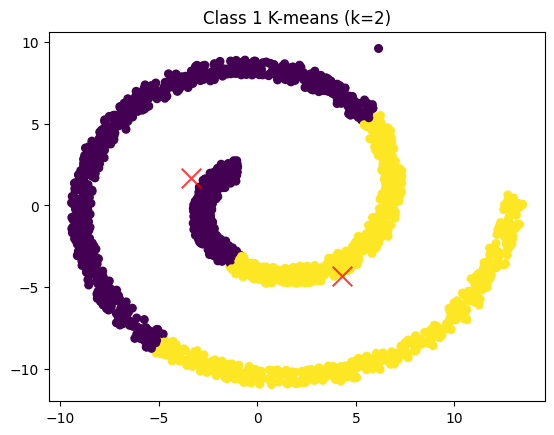

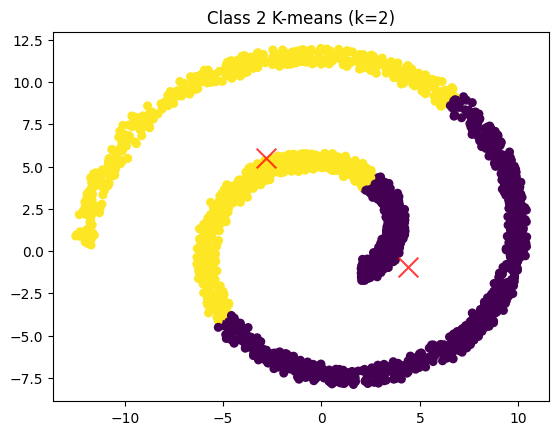


Running GMM for 2 clusters...

Class 1 GMM done.
Class 2 GMM done.

Running K-means for 4 clusters...

Class 1 K-means done.
Class 2 K-means done.


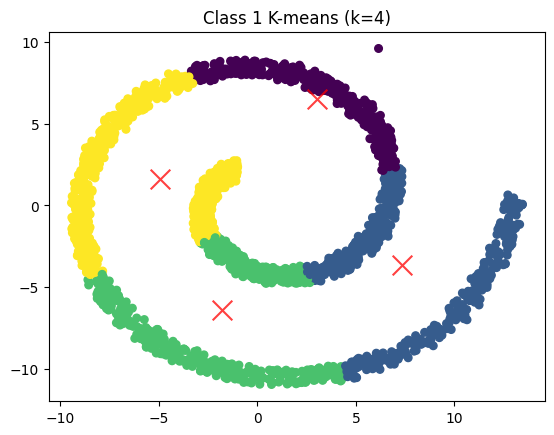

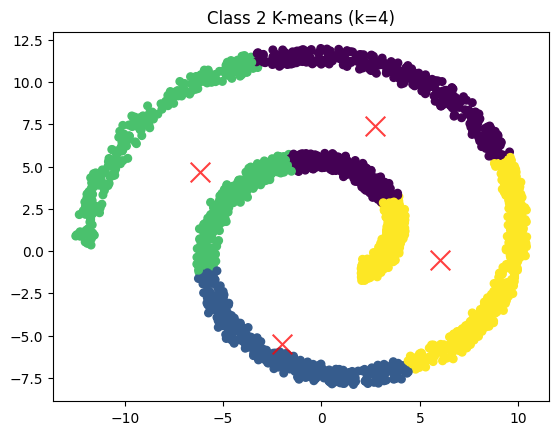


Running GMM for 4 clusters...

Class 1 GMM done.
Class 2 GMM done.

Running K-means for 8 clusters...

Class 1 K-means done.
Class 2 K-means done.


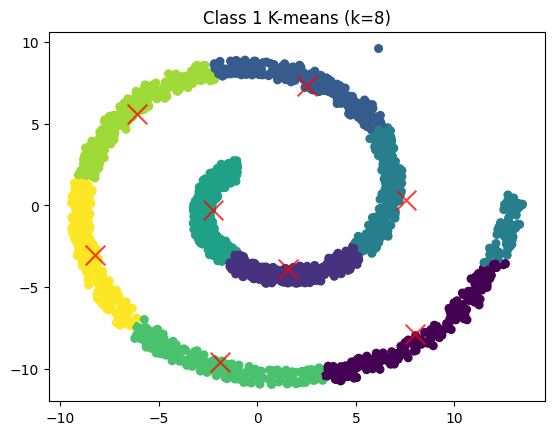

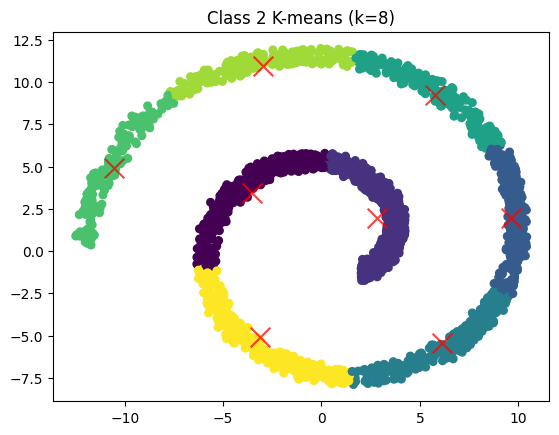


Running GMM for 8 clusters...

Class 1 GMM done.
Class 2 GMM done.


In [10]:
# Main function to run K-means and GMM on the two classes
def main():
    K = [2, 4, 8]  # Different cluster numbers to try
    dims = 2  # Assuming the data has 2 dimensions for simplicity (you can adapt if needed)

    # Define the same colormap for both classes
    cmap = plt.get_cmap('viridis', 8)  # Use plt.get_cmap() to choose a colormap and restrict to 8 colors

    for k in K:
        print(f"\nRunning K-means for {k} clusters...\n")

        # Perform K-means on class1_data
        centroids1, clusters1 = kmeans(class1_data, k)
        print("Class 1 K-means done.")
        
        # Perform K-means on class2_data
        centroids2, clusters2 = kmeans(class2_data, k)
        print("Class 2 K-means done.")

        # Plotting the K-means clusters with consistent color scheme
        plot_clusters(class1_data, clusters1, centroids1, f"Class 1 K-means (k={k})", cmap)
        plot_clusters(class2_data, clusters2, centroids2, f"Class 2 K-means (k={k})", cmap)

        print(f"\nRunning GMM for {k} clusters...\n")

        # Perform GMM on class1_data
        mu1, cov1, pi1, gamma1 = gmm(class1_data, k)
        print("Class 1 GMM done.")
        
        # Perform GMM on class2_data
        mu2, cov2, pi2, gamma2 = gmm(class2_data, k)
        print("Class 2 GMM done.")

if __name__ == "__main__":
    main()


In [11]:
# Function to plot both Class 1 and Class 2 on the same plot
def plot_clusters_both_classes(data1, clusters1, centroids1, data2, clusters2, centroids2, title, cmap):
    plt.scatter(data1[:, 0], data1[:, 1], c=clusters1, s=30, cmap=cmap, label='Class 1')
    plt.scatter(data2[:, 0], data2[:, 1], c=clusters2, s=30, cmap=cmap, marker='x', label='Class 2')
    plt.scatter(centroids1[:, 0], centroids1[:, 1], c='red', s=200, alpha=0.75, marker='x', label='Centroids Class 1')
    plt.scatter(centroids2[:, 0], centroids2[:, 1], c='blue', s=200, alpha=0.75, marker='x', label='Centroids Class 2')
    plt.title(title)
    plt.legend()
    plt.show()



Running K-means for 2 clusters...

Class 1 K-means done.
Class 2 K-means done.


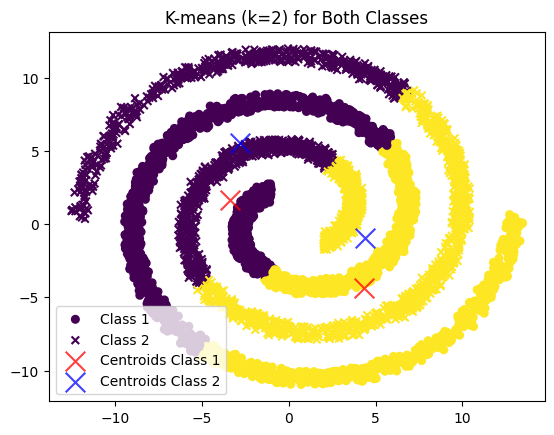


Running GMM for 2 clusters...



ValueError: not enough values to unpack (expected 5, got 4)

In [13]:
K = [2, 4, 8, 16]  # Different cluster numbers to try
dims = 2  # Assuming the data has 2 dimensions for simplicity (you can adapt if needed)

# Define the same colormap for both classes
cmap = plt.get_cmap('viridis', 8)  # Use plt.get_cmap() to choose a colormap and restrict to 8 colors

for k in K:
    print(f"\nRunning K-means for {k} clusters...\n")

    # Perform K-means on class1_data
    centroids1, clusters1 = kmeans(class1_data, k)
    print("Class 1 K-means done.")
    
    # Perform K-means on class2_data
    centroids2, clusters2 = kmeans(class2_data, k)
    print("Class 2 K-means done.")

    # Plotting the K-means clusters of both classes in the same plot
    plot_clusters_both_classes(class1_data, clusters1, centroids1, class2_data, clusters2, centroids2, f"K-means (k={k}) for Both Classes", cmap)

    print(f"\nRunning GMM for {k} clusters...\n")

    # Perform GMM on class1_data
    mu1, cov1, pi1, gamma1, log_likelihoods1 = gmm(class1_data, k)
    print("Class 1 GMM done.")
    
    # Perform GMM on class2_data
    mu2, cov2, pi2, gamma2, log_likelihoods2 = gmm(class2_data, k)
    print("Class 2 GMM done.")


In [19]:
# Function for computing the Gaussian PDF for a given point, mean, and covariance
def gaussian_pdf(x, mean, cov):
    """Multivariate Gaussian probability density function."""
    d = len(mean)
    exponent = -0.5 * np.dot((x - mean).T, np.linalg.solve(cov, (x - mean)))
    denominator = np.sqrt((2 * np.pi) ** d * np.linalg.det(cov))
    return np.exp(exponent) / denominator

# Function to compute the log-likelihood of the GMM model
def compute_log_likelihood(data, weights, means, covariances, k):
    n = len(data)
    log_likelihood = 0
    for i in range(n):
        prob_sum = 0
        for j in range(k):
            prob_sum += weights[j] * gaussian_pdf(data[i], means[j], covariances[j])
        log_likelihood += np.log(prob_sum)
    return log_likelihood

# Function for Gaussian Mixture Model (GMM) using Expectation-Maximization (EM)
def gmm(data, k, max_iterations=100):
    n, d = data.shape

    # Step 1: Initialize GMM parameters
    weights = np.ones(k) / k  # Uniform weights
    means = initialize_centroids(data, k)  # Initialize means using k-means centroids
    covariances = np.array([np.cov(data, rowvar=False) for _ in range(k)])  # Initial covariance matrices

    log_likelihoods = []  # To store log-likelihood at each iteration

    # Step 2: EM algorithm
    for iteration in range(max_iterations):
        # E-step: Calculate responsibilities
        responsibilities = np.zeros((n, k))
        for i in range(k):
            for j in range(n):
                responsibilities[j, i] = weights[i] * gaussian_pdf(data[j], means[i], covariances[i])
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)  # Normalize

        # M-step: Update weights, means, and covariances
        Nk = responsibilities.sum(axis=0)  # Effective number of points assigned to each cluster
        weights = Nk / n
        means = np.dot(responsibilities.T, data) / Nk[:, None]
        covariances = np.zeros((k, d, d))
        for i in range(k):
            diff = data - means[i]
            covariances[i] = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]

        # Compute log-likelihood after M-step
        log_likelihood = compute_log_likelihood(data, weights, means, covariances, k)
        log_likelihoods.append(log_likelihood)

        print(f"Iteration {iteration + 1}: Log-Likelihood = {log_likelihood}")

    return means, covariances, weights, responsibilities, log_likelihoods



Running K-means for 2 clusters...

Class 1 K-means done.
Class 2 K-means done.


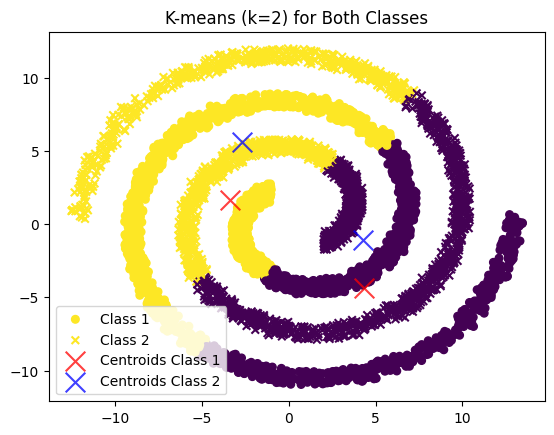


Running GMM for 2 clusters...

Iteration 1: Log-Likelihood = -15280.71328888129
Iteration 2: Log-Likelihood = -15278.528959374593
Iteration 3: Log-Likelihood = -15277.084623202934
Iteration 4: Log-Likelihood = -15275.759689496921
Iteration 5: Log-Likelihood = -15274.305128972619
Iteration 6: Log-Likelihood = -15272.589621572823
Iteration 7: Log-Likelihood = -15270.536806625321
Iteration 8: Log-Likelihood = -15268.115575340727
Iteration 9: Log-Likelihood = -15265.349440880354
Iteration 10: Log-Likelihood = -15262.326048024659
Iteration 11: Log-Likelihood = -15259.19046501815
Iteration 12: Log-Likelihood = -15256.114978756657
Iteration 13: Log-Likelihood = -15253.256131101034
Iteration 14: Log-Likelihood = -15250.720985719041
Iteration 15: Log-Likelihood = -15248.556427187028
Iteration 16: Log-Likelihood = -15246.758530275289
Iteration 17: Log-Likelihood = -15245.290718772503
Iteration 18: Log-Likelihood = -15244.101327459433
Iteration 19: Log-Likelihood = -15243.136249416637
Iteration 

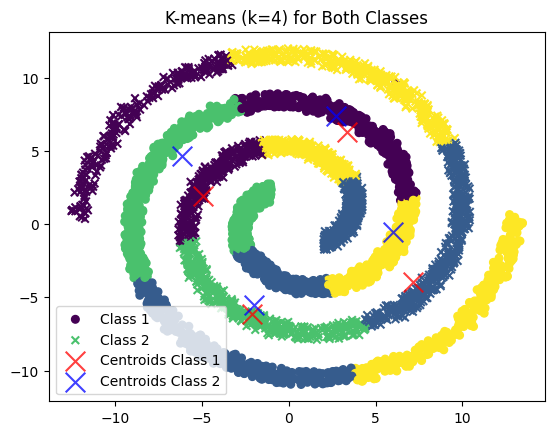


Running GMM for 4 clusters...

Iteration 1: Log-Likelihood = -15220.391910144135
Iteration 2: Log-Likelihood = -15197.90790619798
Iteration 3: Log-Likelihood = -15183.53022060969
Iteration 4: Log-Likelihood = -15170.093543212588
Iteration 5: Log-Likelihood = -15155.427664608858
Iteration 6: Log-Likelihood = -15137.342874132677
Iteration 7: Log-Likelihood = -15112.284705726632
Iteration 8: Log-Likelihood = -15074.796175936533
Iteration 9: Log-Likelihood = -15023.293702823143
Iteration 10: Log-Likelihood = -14972.216993942307
Iteration 11: Log-Likelihood = -14927.960711084086
Iteration 12: Log-Likelihood = -14873.257770759887
Iteration 13: Log-Likelihood = -14782.503400184542
Iteration 14: Log-Likelihood = -14666.884370616111
Iteration 15: Log-Likelihood = -14593.501805151565
Iteration 16: Log-Likelihood = -14557.483562319287
Iteration 17: Log-Likelihood = -14540.916989658564
Iteration 18: Log-Likelihood = -14532.41445015202
Iteration 19: Log-Likelihood = -14526.99956783399
Iteration 20

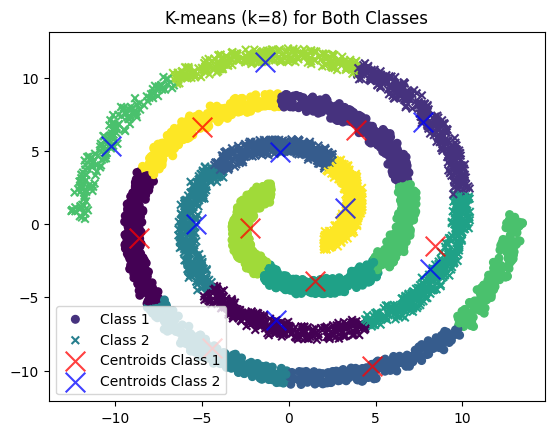


Running GMM for 8 clusters...

Iteration 1: Log-Likelihood = -15235.73611423941
Iteration 2: Log-Likelihood = -15213.334392251478
Iteration 3: Log-Likelihood = -15200.950468880103
Iteration 4: Log-Likelihood = -15190.982089930108
Iteration 5: Log-Likelihood = -15181.095857392997
Iteration 6: Log-Likelihood = -15169.443600955085
Iteration 7: Log-Likelihood = -15153.290462006718
Iteration 8: Log-Likelihood = -15128.239757580975
Iteration 9: Log-Likelihood = -15090.346122395702
Iteration 10: Log-Likelihood = -15043.193753470165
Iteration 11: Log-Likelihood = -14994.997230417015
Iteration 12: Log-Likelihood = -14946.488971899656
Iteration 13: Log-Likelihood = -14891.769480932124
Iteration 14: Log-Likelihood = -14824.057350864008
Iteration 15: Log-Likelihood = -14729.201285668836
Iteration 16: Log-Likelihood = -14586.2021140495
Iteration 17: Log-Likelihood = -14460.532301748
Iteration 18: Log-Likelihood = -14352.23634026474
Iteration 19: Log-Likelihood = -14138.976909706771
Iteration 20: L

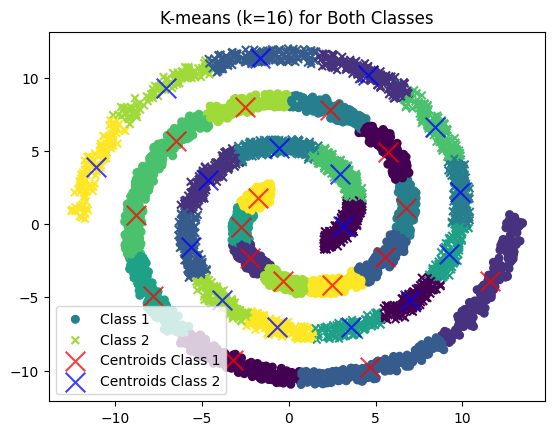


Running GMM for 16 clusters...

Iteration 1: Log-Likelihood = -15216.212093087624
Iteration 2: Log-Likelihood = -15180.843980137277
Iteration 3: Log-Likelihood = -15142.032286731908
Iteration 4: Log-Likelihood = -15085.5124514487
Iteration 5: Log-Likelihood = -15000.511210507208
Iteration 6: Log-Likelihood = -14896.708350442716
Iteration 7: Log-Likelihood = -14791.854000534535
Iteration 8: Log-Likelihood = -14664.670819882032
Iteration 9: Log-Likelihood = -14488.942307788238
Iteration 10: Log-Likelihood = -14285.34291672753
Iteration 11: Log-Likelihood = -14077.15292371882
Iteration 12: Log-Likelihood = -13922.467982812692
Iteration 13: Log-Likelihood = -13750.022848740167
Iteration 14: Log-Likelihood = -13531.339801769202
Iteration 15: Log-Likelihood = -13381.609686001953
Iteration 16: Log-Likelihood = -13270.699024396548
Iteration 17: Log-Likelihood = -13150.866296043943
Iteration 18: Log-Likelihood = -12994.930053602671
Iteration 19: Log-Likelihood = -12743.144389006557
Iteration 2

In [20]:
K = [2, 4, 8, 16]  # Different cluster numbers to try
dims = 2  # Assuming the data has 2 dimensions for simplicity (you can adapt if needed)

# Define the same colormap for both classes
cmap = plt.get_cmap('viridis', 8)  # Use plt.get_cmap() to choose a colormap and restrict to 8 colors

for k in K:
    print(f"\nRunning K-means for {k} clusters...\n")

    # Perform K-means on class1_data
    centroids1, clusters1 = kmeans(class1_data, k)
    print("Class 1 K-means done.")
    
    # Perform K-means on class2_data
    centroids2, clusters2 = kmeans(class2_data, k)
    print("Class 2 K-means done.")

    # Plotting the K-means clusters of both classes in the same plot
    plot_clusters_both_classes(class1_data, clusters1, centroids1, class2_data, clusters2, centroids2, f"K-means (k={k}) for Both Classes", cmap)

    print(f"\nRunning GMM for {k} clusters...\n")

    # Perform GMM on class1_data
    mu1, cov1, pi1, gamma1, log_likelihoods1 = gmm(class1_data, k)
    print("Class 1 GMM done.")
    
    # Perform GMM on class2_data
    mu2, cov2, pi2, gamma2, log_likelihoods2 = gmm(class2_data, k)
    print("Class 2 GMM done.")
